## Class7- Case Study2

In [22]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [23]:
# ----------------------------
# 0) Setup: styles & RNG seed
# ----------------------------
sns.set(style="whitegrid", context="talk")
RANDOM_STATE = 42

# ----------------------------
# 1) Load the data
# ----------------------------
CSV_NAME = "DataSets/cereal.csv"
if not os.path.exists(CSV_NAME):
    sys.exit(f"❌ Could not find '{CSV_NAME}' in {os.getcwd()}. "
             "Place the file in this folder and re-run.")

df = pd.read_csv(CSV_NAME)

print("Data loaded. Shape:", df.shape)
print("The first 5 rows of data are:\n")
print(df.head)
print("\n\n\nDataset has {} rows and {} columns".format(df.shape[0], df.shape[1]))
print("\n\n\nDatatype: \n")
print(df.dtypes)
print("\n\n\nThe number of null values for each column are: \n")
print(df.isnull().sum())
print("\n\n\nData summary: \n")
print(df.describe())

Data loaded. Shape: (77, 16)
The first 5 rows of data are:

<bound method NDFrame.head of                          name mfr type  calories  protein  fat  sodium  fiber  \
0                   100% Bran   N    C        70        4    1     130   10.0   
1           100% Natural Bran   Q    C       120        3    5      15    2.0   
2                    All-Bran   K    C        70        4    1     260    9.0   
3   All-Bran with Extra Fiber   K    C        50        4    0     140   14.0   
4              Almond Delight   R    C       110        2    2     200    1.0   
..                        ...  ..  ...       ...      ...  ...     ...    ...   
72                    Triples   G    C       110        2    1     250    0.0   
73                       Trix   G    C       110        1    1     140    0.0   
74                 Wheat Chex   R    C       100        3    1     230    3.0   
75                   Wheaties   G    C       100        3    1     200    3.0   
76        Wheaties 

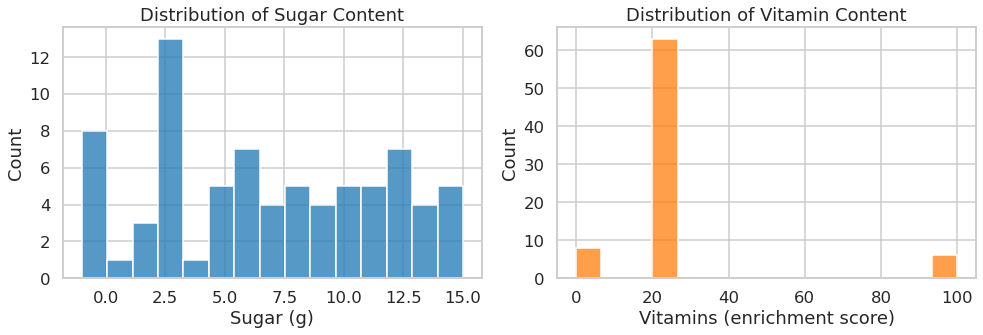

In [24]:
# ----------------------------
# 2) EDA: Histograms for sugar & vitamins
# ----------------------------

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["sugars"].dropna(), kde=False, bins=15, color="#1f77b4")
plt.title("Distribution of Sugar Content")
plt.xlabel("Sugar (g)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.histplot(df["vitamins"].dropna(), kde=False, bins=15, color="#ff7f0e")
plt.title("Distribution of Vitamin Content")
plt.xlabel("Vitamins (enrichment score)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

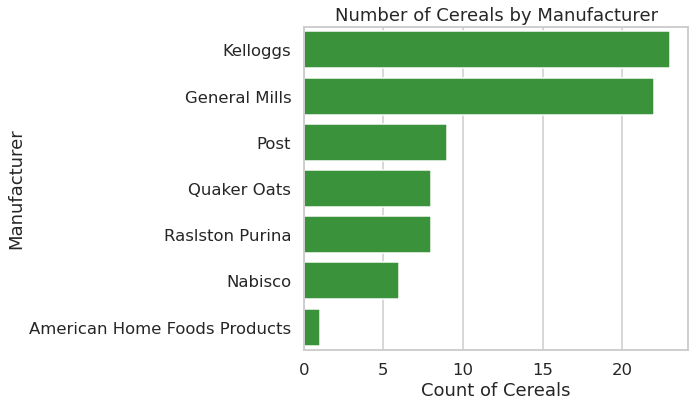

In [25]:

# ----------------------------
# 3) Manufacturer mapping & count plot
# ----------------------------
# The PDF specifies single-letter manufacturer codes with this mapping:
#  'N': 'Nabisco',
#  'Q': 'Quaker Oats',
#  'K': 'Kelloggs',
#  'R': 'Raslston Purina',
#  'G': 'General Mills',
#  'P': 'Post',
#  'A': 'American Home Foods Products'
# (We keep spelling as given in the case study.)

mfr_map = {
    'N': 'Nabisco',
    'Q': 'Quaker Oats',
    'K': 'Kelloggs',
    'R': 'Raslston Purina',
    'G': 'General Mills',
    'P': 'Post',
    'A': 'American Home Foods Products'
}

df["Manufacturer"] = df["mfr"].map(mfr_map).fillna("Unknown")

plt.figure(figsize=(10, 6))
# Count plot with manufacturers on Y axis as required
order = df["Manufacturer"].value_counts().index
sns.countplot(y="Manufacturer", data=df, order=order, color="#2ca02c")
plt.title("Number of Cereals by Manufacturer")
plt.xlabel("Count of Cereals")
plt.ylabel("Manufacturer")
plt.tight_layout()
plt.show()


In [26]:

# ----------------------------
# 4) Prepare features (X) and target (y)
# ----------------------------
# Extract rating as target 'y' and all numerical parameters as predictors 'X'.
rating_col = find_col(["rating", "ratings"], df.columns)
if rating_col is None:
    sys.exit(f"❌ Missing expected target column 'rating'. Found columns: {list(df.columns)}")

y = df["rating"].astype(float)

# Numeric predictors only; exclude the target itself
numeric_df = df.select_dtypes(include=[np.number]).copy()
if "rating" in numeric_df.columns:
    X = numeric_df.drop(columns=["rating"])
else:
    X = numeric_df

# A gentle check: drop columns with all-NaN or zero variance
X = X.dropna(axis=1, how="all")
if X.shape[1] == 0:
    sys.exit("❌ No numeric predictors available after cleaning.")
if (X.nunique(dropna=False) <= 1).any():
    # Drop any constant columns (zero variance)
    const_cols = X.columns[(X.nunique(dropna=False) <= 1)]
    X = X.drop(columns=const_cols)

# Align X,y on non-missing rows
mask = (~X.isna().any(axis=1)) & (~y.isna())
X_clean = X[mask]
y_clean = y[mask]

print(f"Predictors shape after cleaning: {X_clean.shape}")
print(f"Target length after cleaning: {y_clean.shape[0]}")

# ----------------------------
# 5) Train/test split (25% test)
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Split -> X_train: {X_train.shape}, X_test: {X_test.shape}")

# ----------------------------
# 6) Fit Linear Regression & evaluate MSE
# ----------------------------
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("\n📊 Linear Regression Results")
print("-" * 32)
print(f"Test MSE: {mse:.4f}")
print(f"R^2 on train: {linreg.score(X_train, y_train):.4f}")
print(f"R^2 on test : {linreg.score(X_test, y_test):.4f}")

# Optional: show top coefficients by magnitude to interpret
coefs = pd.Series(linreg.coef_, index=X_train.columns).sort_values(key=np.abs, ascending=False)
print("\nTop coefficients (by |magnitude|):")
print(coefs.head(10))


Predictors shape after cleaning: (77, 12)
Target length after cleaning: 77
Split -> X_train: (57, 12), X_test: (20, 12)

📊 Linear Regression Results
--------------------------------
Test MSE: 0.0000
R^2 on train: 1.0000
R^2 on test : 1.0000

Top coefficients (by |magnitude|):
fiber       3.443480e+00
protein     3.273174e+00
fat        -1.691408e+00
carbo       1.092451e+00
sugars     -7.248951e-01
calories   -2.227242e-01
sodium     -5.449270e-02
vitamins   -5.121197e-02
potass     -3.399335e-02
weight      2.222326e-07
dtype: float64
